In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

print("Model Explainability Started")

Model Explainability Started


In [2]:
# Load trained model

model_path = "../models/churn_model.pkl"

model = joblib.load(model_path)

print("Model loaded successfully!")
print(type(model))

Model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


# Feature Name

In [4]:
# Get preprocessing part of the pipeline
preprocessor = model.named_steps["preprocessor"]
# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()
print("Total Features:", len(feature_names))
print("\nFeature Names:")
for feature in feature_names:
    print(feature)

Total Features: 50

Feature Names:
num__SeniorCitizen
num__tenure
num__MonthlyCharges
num__TotalCharges
num__Average_Monthly_Spend
num__Customer_Lifetime_Months
num__Service_Count
num__High_Monthly_Charge
num__Short_Tenure
cat__gender_Female
cat__gender_Male
cat__Partner_No
cat__Partner_Yes
cat__Dependents_No
cat__Dependents_Yes
cat__PhoneService_No
cat__PhoneService_Yes
cat__MultipleLines_No
cat__MultipleLines_No phone service
cat__MultipleLines_Yes
cat__InternetService_DSL
cat__InternetService_Fiber optic
cat__InternetService_No
cat__OnlineSecurity_No
cat__OnlineSecurity_No internet service
cat__OnlineSecurity_Yes
cat__OnlineBackup_No
cat__OnlineBackup_No internet service
cat__OnlineBackup_Yes
cat__DeviceProtection_No
cat__DeviceProtection_No internet service
cat__DeviceProtection_Yes
cat__TechSupport_No
cat__TechSupport_No internet service
cat__TechSupport_Yes
cat__StreamingTV_No
cat__StreamingTV_No internet service
cat__StreamingTV_Yes
cat__StreamingMovies_No
cat__StreamingMovies_N

# To extract the Top Churn Factors using the actual Logistic Regression coefficients.

In [ ]:
# Show all steps inside our trained model
print("Model Pipeline Steps:")
print()

for name, step in model.named_steps.items():
    print("Step Name:", name)
    print("Step Type:", type(step))
    print("-" * 50)

Model Pipeline Steps:

Step Name: preprocessor
Step Type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
--------------------------------------------------
Step Name: model
Step Type: <class 'sklearn.linear_model._logistic.LogisticRegression'>
--------------------------------------------------


# Actual Feature Importance

In [7]:
# Get the trained Logistic Regression model
classifier = model.named_steps["model"]
# Get coefficients
coefficients = classifier.coef_[0]
# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": coefficients
})
# Absolute importance
feature_importance["Absolute_Importance"] = (
    feature_importance["Importance"].abs()
)
# Sort by absolute importance
feature_importance = feature_importance.sort_values(
    by="Absolute_Importance",
    ascending=False
)
# Show top 15 features
print("Top 15 Important Features:")
print(
    feature_importance[
        ["Feature", "Importance"]
    ].head(15)
)

Top 15 Important Features:
                                      Feature  Importance
43                     cat__Contract_Two year   -0.833214
20                   cat__InternetService_DSL   -0.718671
21           cat__InternetService_Fiber optic    0.686533
41               cat__Contract_Month-to-month    0.613896
2                         num__MonthlyCharges   -0.507333
1                                 num__tenure   -0.399898
5               num__Customer_Lifetime_Months   -0.399898
44                   cat__PaperlessBilling_No   -0.344604
17                      cat__MultipleLines_No   -0.314259
30  cat__DeviceProtection_No internet service   -0.277057
22                    cat__InternetService_No   -0.277057
24    cat__OnlineSecurity_No internet service   -0.277057
33       cat__TechSupport_No internet service   -0.277057
36       cat__StreamingTV_No internet service   -0.277057
39   cat__StreamingMovies_No internet service   -0.277057


# Feature Importance Chart

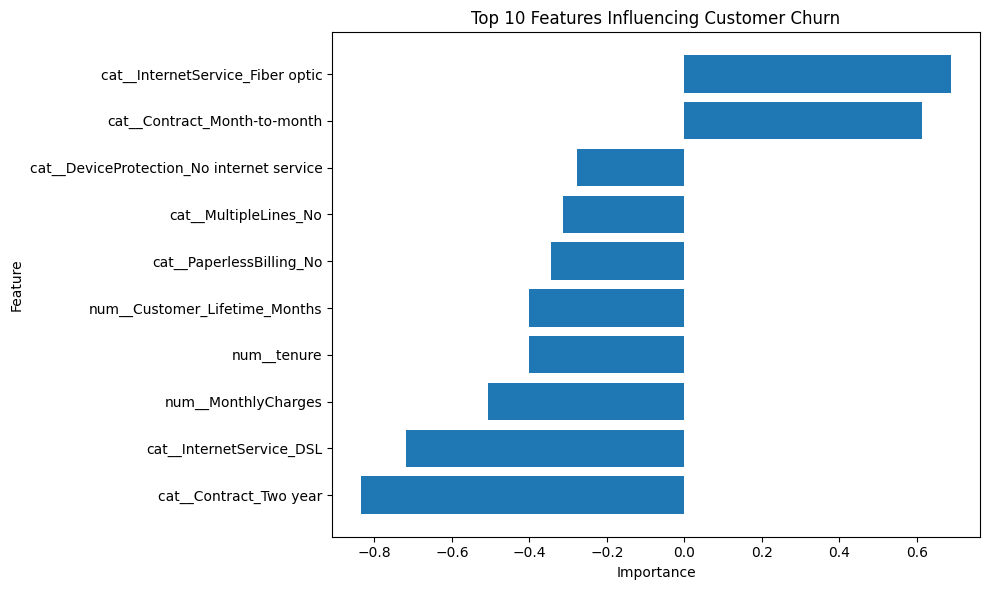

In [ ]:
import matplotlib.pyplot as plt
# Get top 10 features
top_features = feature_importance.head(10).copy()
# Reverse order for better horizontal bar chart
top_features = top_features.sort_values(
    by="Importance"
)
# Create chart
plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(
    "Top 10 Features Influencing Customer Churn"
)
plt.tight_layout()
plt.show()

# separate the Churn Factors into Positive and Negative factors.

In [9]:
# =====================================================
# POSITIVE AND NEGATIVE CHURN FACTORS
# =====================================================

# Factors that increase churn
positive_factors = feature_importance[
    feature_importance["Importance"] > 0
].sort_values(
    by="Importance",
    ascending=False
).head(10)

# Factors that reduce churn
negative_factors = feature_importance[
    feature_importance["Importance"] < 0
].sort_values(
    by="Importance",
    ascending=True
).head(10)

print("=" * 60)
print("FACTORS THAT INCREASE CHURN")
print("=" * 60)

print(
    positive_factors[
        ["Feature", "Importance"]
    ].to_string(index=False)
)

print("\n")
print("=" * 60)
print("FACTORS THAT REDUCE CHURN")
print("=" * 60)

print(
    negative_factors[
        ["Feature", "Importance"]
    ].to_string(index=False)
)

FACTORS THAT INCREASE CHURN
                            Feature  Importance
   cat__InternetService_Fiber optic    0.686533
       cat__Contract_Month-to-month    0.613896
                  num__TotalCharges    0.261819
                  num__Short_Tenure    0.247307
                 num__Service_Count    0.241371
             cat__OnlineSecurity_No    0.197405
cat__PaymentMethod_Electronic check    0.193382
                cat__TechSupport_No    0.167559
           cat__StreamingMovies_Yes    0.149786
               cat__StreamingTV_Yes    0.148523


FACTORS THAT REDUCE CHURN
                                  Feature  Importance
                   cat__Contract_Two year   -0.833214
                 cat__InternetService_DSL   -0.718671
                      num__MonthlyCharges   -0.507333
                              num__tenure   -0.399898
            num__Customer_Lifetime_Months   -0.399898
                 cat__PaperlessBilling_No   -0.344604
                    cat__MultipleLines

# Save the Feature Importance to a CSV file

In [10]:
# =====================================================
# SAVE FEATURE IMPORTANCE
# =====================================================

import os
# Create reports folder if it does not exist
os.makedirs("../reports", exist_ok=True)

# Save complete feature importance
feature_importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

print("✅ Feature importance saved successfully!")

print(
    "File location:"
)

print(
    "../reports/feature_importance.csv"
)

✅ Feature importance saved successfully!
File location:
../reports/feature_importance.csv
